# Maintenance Configuration Results Analysis

This notebook imports and analyzes simulation results for different maintenance configurations.

In [1]:
result_types = ["results", "bike_movements", "hourly", "station_hourly", 
                    "trip_requests", "vehicle_visits"]

results_dfs = {}
hourly_dfs = {}


In [2]:
# Load the new CSV files and add them to hourly_dfs
import pandas as pd
from pathlib import Path
import os

# Get current working directory and navigate to the base path
# Notebook is in FOMOsim/policies/sjovik_sund/Scripts/
# Need to go up 3 levels to FOMOsim root, then down to simulation results
current_dir = Path(os.getcwd())
csv_base_path = current_dir.parent.parent.parent / "policies" / "sjovik_sund" / "simulation_results" / "Result_different_maintenance_configurations"

# Load the CSV files
hourly_dfs["0.25"] = pd.read_csv(csv_base_path / "TESTMAINTENANCE_FULLWEEK_0.0025_2.csv")
hourly_dfs["0.5"] = pd.read_csv(csv_base_path / "TESTMAINTENANCE_FULLWEEK_0.005_2.csv")
hourly_dfs["0.125"] = pd.read_csv(csv_base_path / "TESTMAINTENANCE_FULLWEEK_0.00125_2.csv")
hourly_dfs["0.075"] = pd.read_csv(csv_base_path / "TESTMAINTENANCE_FULLWEEK_0.00075_2.csv")


print(f"\nTotal configurations available: {list(hourly_dfs.keys())}")


Total configurations available: ['0.25', '0.5', '0.125', '0.075']


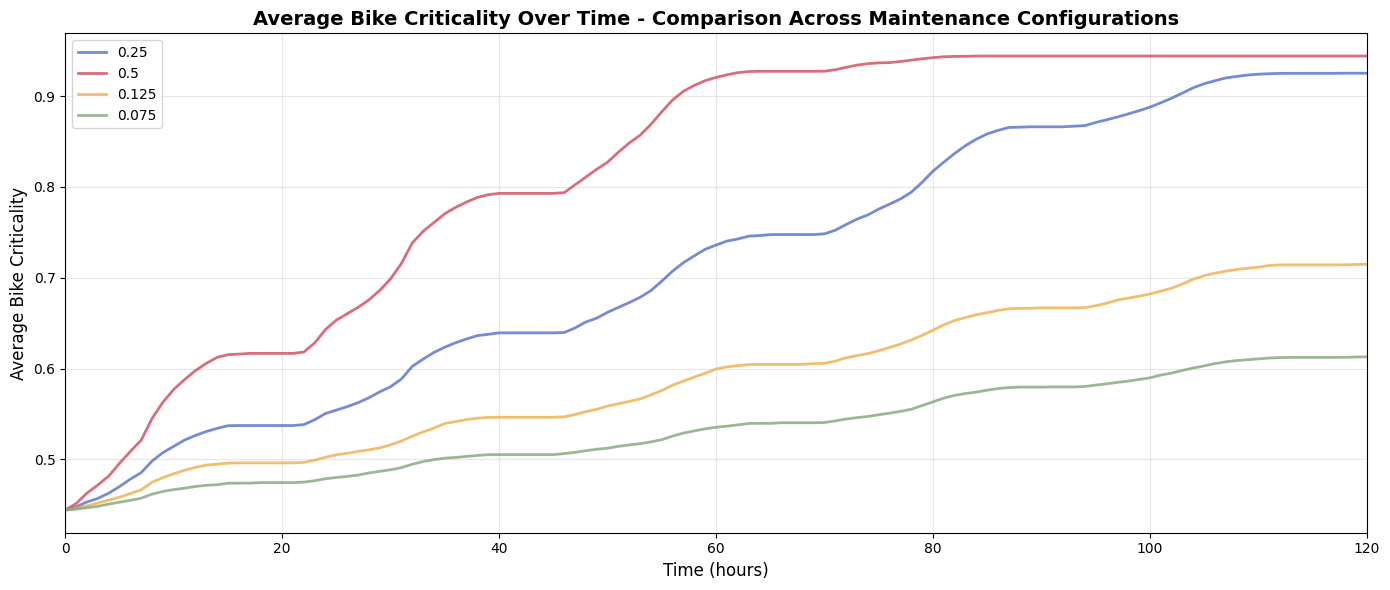


Summary Statistics - Average Bike Criticality:

0.25:
  Mean: 0.7185
  Min:  0.4443
  Max:  0.9251
  Std:  0.1508

0.5:
  Mean: 0.8200
  Min:  0.4443
  Max:  0.9440
  Std:  0.1527

0.125:
  Mean: 0.5918
  Min:  0.4443
  Max:  0.7148
  Std:  0.0824

0.075:
  Mean: 0.5338
  Min:  0.4443
  Max:  0.6129
  Std:  0.0513


In [ ]:
import matplotlib.pyplot as plt

swatches = [
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

# Select three colors for the three configurations
colors = ["#526ECA",  "#D1495B", "#EDAE49", "#84A579", "#344E41"]  # Blue Accent, Ochre Gold, Warm Red

# Create figure
plt.figure(figsize=(14, 6))

# Plot average bike criticality for each configuration
for i, (config_name, df) in enumerate(hourly_dfs.items()):
    # Convert time to hours and subtract 7 to start at t=0
    time_hours = (df['Time (minutes)'] / 60) - 7
    
    plt.plot(time_hours, df['Avg Bike Criticality'], 
             label=config_name, linewidth=2, alpha=0.8, color=colors[i % len(colors)])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Average Bike Criticality', fontsize=12)
#plt.title('Average Bike Criticality Over Time - Comparison Across Maintenance Configurations', fontsize=14, fontweight='bold')
plt.xlim(0, 120)  # Start at 0, end at 120 hours
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('average_bike_criticality_comparison_full.svg')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics - Average Bike Criticality:")
print("="*80)
for config_name, df in hourly_dfs.items():
    avg_crit = df['Avg Bike Criticality'].mean()
    min_crit = df['Avg Bike Criticality'].min()
    max_crit = df['Avg Bike Criticality'].max()
    std_crit = df['Avg Bike Criticality'].std()
    print(f"\n{config_name}:")
    print(f"  Mean: {avg_crit:.4f}")
    print(f"  Min:  {min_crit:.4f}")
    print(f"  Max:  {max_crit:.4f}")
    print(f"  Std:  {std_crit:.4f}")

In [4]:
## Maintenance Violations Comparison Across Configurations

Maintenance Violations Analysis

0.25:
  Total Maintenance Violations: 744
  Avg Violations per Hour: 6.10
  Max Violations per Hour: 28
  Total Maintenance Starvations: 3128
  Avg Maintenance Starvations per Hour: 25.64

0.5:
  Total Maintenance Violations: 759
  Avg Violations per Hour: 6.22
  Max Violations per Hour: 52
  Total Maintenance Starvations: 4637
  Avg Maintenance Starvations per Hour: 38.01

0.125:
  Total Maintenance Violations: 193
  Avg Violations per Hour: 1.58
  Max Violations per Hour: 8
  Total Maintenance Starvations: 1131
  Avg Maintenance Starvations per Hour: 9.27

0.075:
  Total Maintenance Violations: 87
  Avg Violations per Hour: 0.71
  Max Violations per Hour: 4
  Total Maintenance Starvations: 663
  Avg Maintenance Starvations per Hour: 5.43


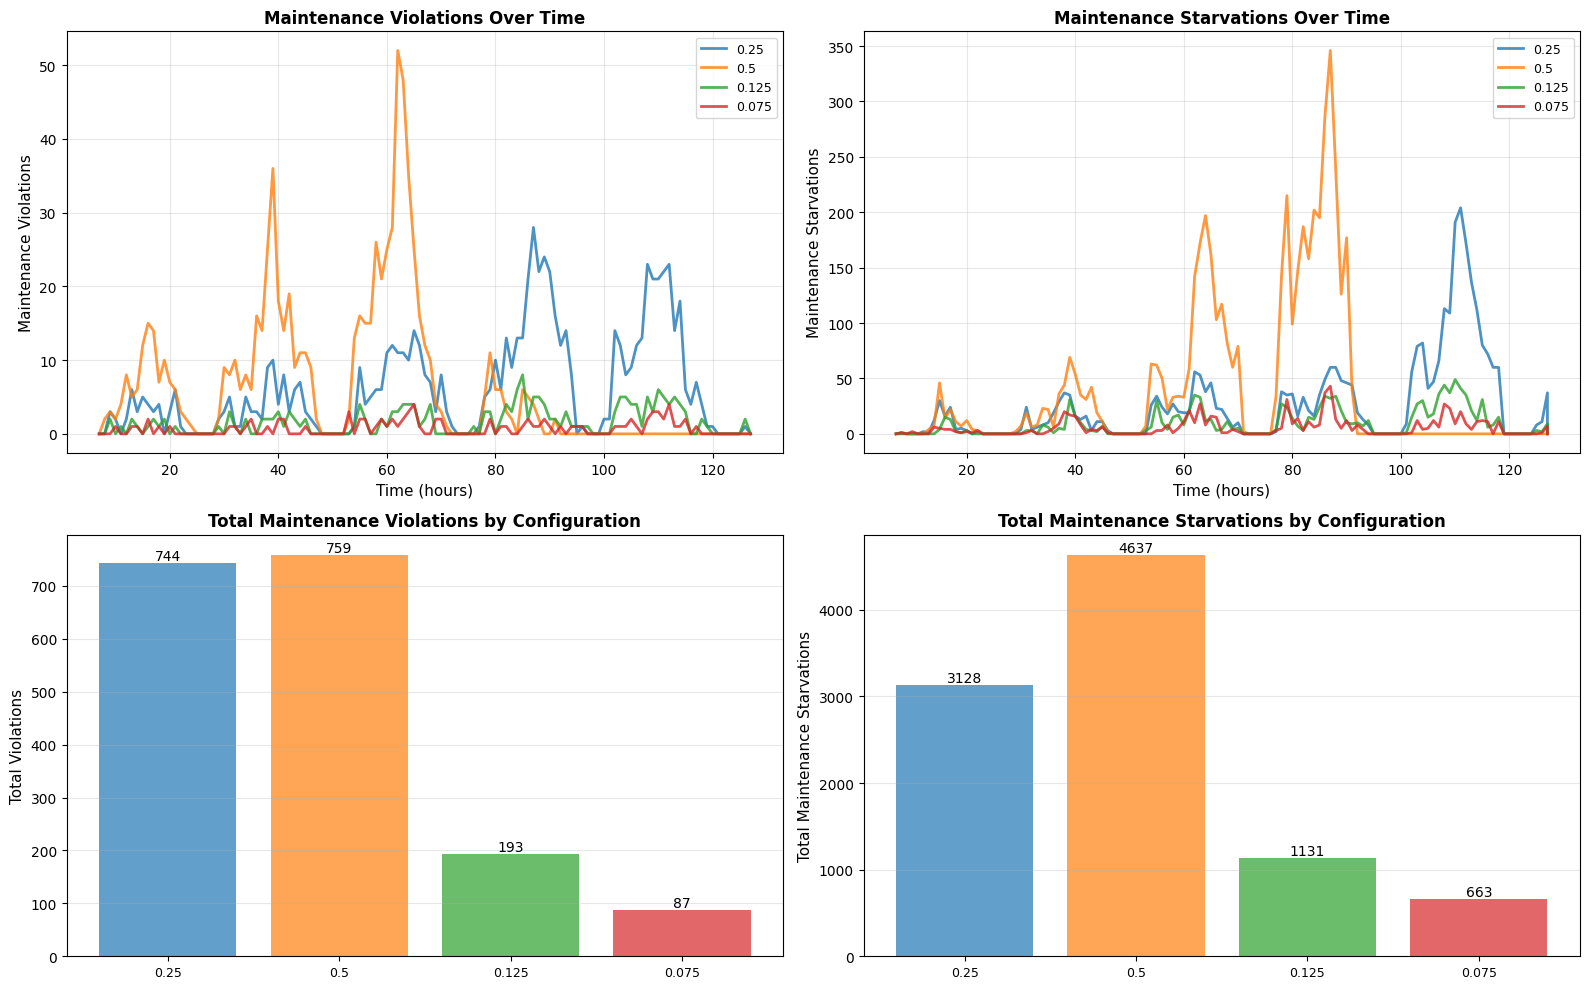

In [5]:
def compare_maintenance_violations(hourly_dfs, plot=True):
    """
    Compare maintenance violations across different configurations.
    
    Parameters:
    -----------
    hourly_dfs : dict
        Dictionary of hourly dataframes for each configuration
    plot : bool
        Whether to create visualization plots (default: True)
    
    Returns:
    --------
    dict
        Dictionary with violation statistics for each configuration
    """
    violation_stats = {}
    
    print("Maintenance Violations Analysis")
    print("="*80)
    
    for config_name, df in hourly_dfs.items():
        # Calculate statistics
        total_violations = df['Maintenance Violations'].sum()
        avg_violations_per_hour = df['Maintenance Violations'].mean()
        max_violations_per_hour = df['Maintenance Violations'].max()
        
        # Calculate maintenance starvations
        total_maint_starvations = df['Maintenance Starvations'].sum()
        avg_maint_starvations_per_hour = df['Maintenance Starvations'].mean()
        
        violation_stats[config_name] = {
            'total_violations': total_violations,
            'avg_violations_per_hour': avg_violations_per_hour,
            'max_violations_per_hour': max_violations_per_hour,
            'total_maint_starvations': total_maint_starvations,
            'avg_maint_starvations_per_hour': avg_maint_starvations_per_hour
        }
        
        print(f"\n{config_name}:")
        print(f"  Total Maintenance Violations: {total_violations}")
        print(f"  Avg Violations per Hour: {avg_violations_per_hour:.2f}")
        print(f"  Max Violations per Hour: {max_violations_per_hour}")
        print(f"  Total Maintenance Starvations: {total_maint_starvations}")
        print(f"  Avg Maintenance Starvations per Hour: {avg_maint_starvations_per_hour:.2f}")
    
    if plot:
        # Create subplots
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # Plot 1: Maintenance Violations over time
        ax1 = axes[0, 0]
        for config_name, df in hourly_dfs.items():
            time_hours = df['Time (minutes)'] / 60
            ax1.plot(time_hours, df['Maintenance Violations'], 
                    label=config_name, linewidth=2, alpha=0.8)
        ax1.set_xlabel('Time (hours)', fontsize=11)
        ax1.set_ylabel('Maintenance Violations', fontsize=11)
        ax1.set_title('Maintenance Violations Over Time', fontsize=12, fontweight='bold')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Maintenance Starvations over time
        ax2 = axes[0, 1]
        for config_name, df in hourly_dfs.items():
            time_hours = df['Time (minutes)'] / 60
            ax2.plot(time_hours, df['Maintenance Starvations'], 
                    label=config_name, linewidth=2, alpha=0.8)
        ax2.set_xlabel('Time (hours)', fontsize=11)
        ax2.set_ylabel('Maintenance Starvations', fontsize=11)
        ax2.set_title('Maintenance Starvations Over Time', fontsize=12, fontweight='bold')
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Total Violations - Bar chart
        ax3 = axes[1, 0]
        configs = list(violation_stats.keys())
        totals = [violation_stats[c]['total_violations'] for c in configs]
        bars = ax3.bar(range(len(configs)), totals, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        ax3.set_xticks(range(len(configs)))
        ax3.set_xticklabels([c.replace('_', '\n') for c in configs], fontsize=9)
        ax3.set_ylabel('Total Violations', fontsize=11)
        ax3.set_title('Total Maintenance Violations by Configuration', fontsize=12, fontweight='bold')
        ax3.grid(True, axis='y', alpha=0.3)
        
        # Add values on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)
        
        # Plot 4: Total Maintenance Starvations - Bar chart
        ax4 = axes[1, 1]
        starvations = [violation_stats[c]['total_maint_starvations'] for c in configs]
        bars = ax4.bar(range(len(configs)), starvations, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        ax4.set_xticks(range(len(configs)))
        ax4.set_xticklabels([c.replace('_', '\n') for c in configs], fontsize=9)
        ax4.set_ylabel('Total Maintenance Starvations', fontsize=11)
        ax4.set_title('Total Maintenance Starvations by Configuration', fontsize=12, fontweight='bold')
        ax4.grid(True, axis='y', alpha=0.3)
        
        # Add values on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return violation_stats

# Run the comparison
violation_stats = compare_maintenance_violations(hourly_dfs, plot=True)

In [6]:
## Bike B572 Analysis - Criticality Development Across Configurations

In [7]:
# Filter bike movements data for bike B572
bike_id = "B513"

b572_data = {}
for config_name, df in bike_movements_dfs.items():
    # Filter for the specific bike
    bike_df = df[df['Bike ID'] == bike_id].copy()
    b572_data[config_name] = bike_df
    print(f"{config_name}: {len(bike_df)} movements for bike {bike_id}")

print(f"\nTotal movements for bike {bike_id} across all configurations:")

NameError: name 'bike_movements_dfs' is not defined

C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_12752\2046520065.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', fontsize=10)


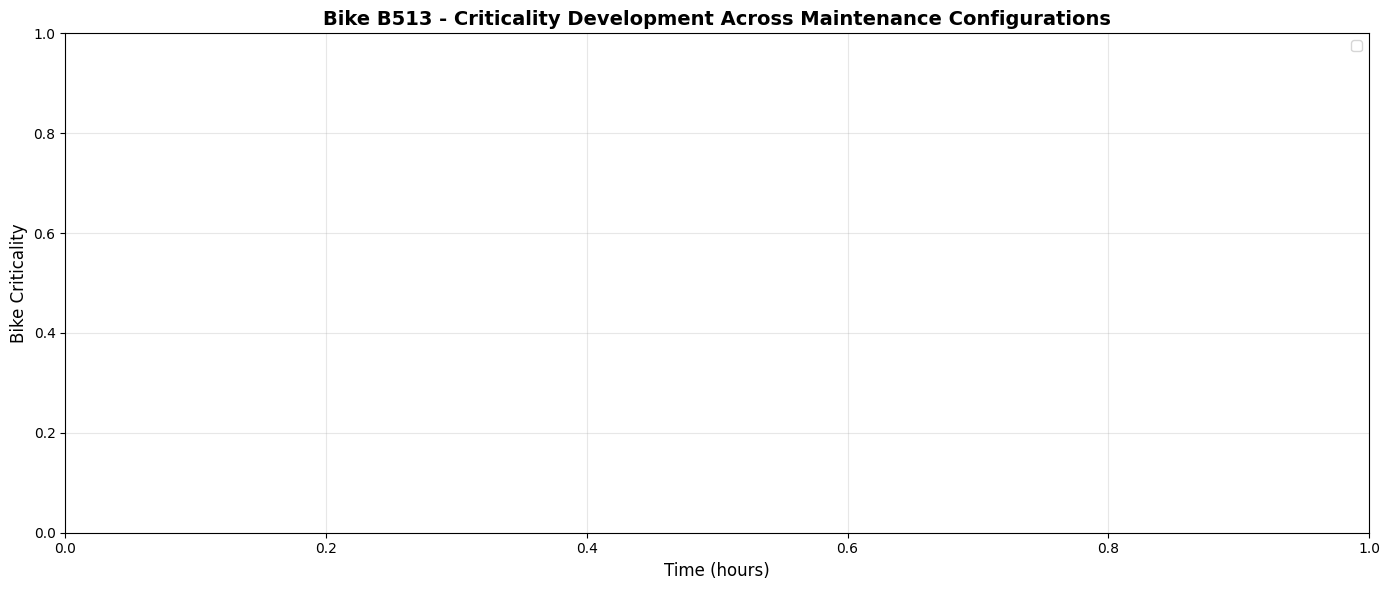

In [ ]:
# Plot criticality development for bike B572 across configurations
plt.figure(figsize=(14, 6))

for config_name, bike_df in b572_data.items():
    if len(bike_df) > 0:
        # Convert time to hours
        time_hours = bike_df['Time (minutes)'] / 60
        
        # Plot bike criticality over time
        plt.plot(time_hours, bike_df['Bike Criticality'], 
                 label=config_name, linewidth=2, alpha=1, marker='o', markersize=3)

plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Bike Criticality', fontsize=12)
plt.title(f'Bike {bike_id} - Criticality Development Across Maintenance Configurations', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
